# The "never wrong" buy signal — is the Zweig Breadth Thrust real? 📈
### The rare 'all-clear' that supposedly always precedes a bull market, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Never_wrong%3F: Busted](https://img.shields.io/badge/Never_wrong%3F-Busted-8b949e?style=flat-square)

Market lore has a legend: Marty Zweig's **Breadth Thrust**. When the stock market goes from *almost nothing rising* to *almost everything rising* in about two weeks, a powerful bull run is supposed to follow — and the signal is said to be **"never wrong."** It's famously rare: roughly **a dozen times in 70 years**.

A perfect record sounds like free money. But "never wrong" out of a dozen tries, in a market that drifts **up** most years anyway, is exactly what *luck* looks like. This notebook shows why the legend is real-as-a-story and empty-as-a-strategy at the same time.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** True NYSE "advancing vs declining" breadth isn't free, so we **build a transparent proxy**: the share of a 40-stock basket that rose each day. It's narrower and noisier than Zweig's NYSE — we call it a proxy throughout — but the lesson (a dozen events can't be a strategy) only gets *stronger* for the rarer real signal. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from zweig_breadth_thrust import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
EVENTS = st.detect_thrusts(F) if HAVE_REAL else None
print("real breadth-proxy cache present:", HAVE_REAL,
      "| thrust events:", (0 if EVENTS is None else len(EVENTS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1995-01-04', 'end': '2026-06-22', 'days': 7918, 'years': 31.5, 'n_events': 22, 'h3': (3, 22, 2.37, 59, 2.93, 71, -0.37, 0.644), 'h6': (6, 22, 6.18, 73, 5.89, 76, 0.13, 0.461), 'h12': (12, 22, 14.99, 91, 12.01, 81, 0.94, 0.207), 'net': [(3, 2.37, 2.32), (6, 6.18, 6.13), (12, 14.99, 14.94)], 'robust': [(0.61, 22, 15.1, 0.99, 0.197), (0.615, 22, 15.0, 0.94, 0.207), (0.65, 15, 15.5, 0.68, 0.22)], 'syn': [(0.0, 15, 8.84, 4.98, 1.19, 0.093), (0.1, 15, 17.3, 7.38, 3.18, 0.001)]}


real breadth-proxy cache present: True | thrust events: 22


## The answer first

| Question | Answer |
|---|---|
| After a thrust, is the market higher a year later? | **Usually — 91% of the time.** That's the "never wrong" headline. |
| Isn't 91% amazing? | **Not really.** Pick *any* random day and the market is higher a year later **81%** of the time. The thrust adds only ~10 points of win-rate — and that gap is well inside the noise. |
| So is the extra return real? | **Can't tell.** The average bump over a normal year is a few percent, but with only **22 events ever** it's statistically indistinguishable from luck (and at **3 months** the thrust actually *underperforms*). |
| Then why the perfect reputation? | **Rarity × an up-drifting market.** Fire a dozen times in a market that mostly rises and you'll look "never wrong" by accident — the same trick as the Hindenburg Omen, in reverse. |

> The thrust is a real, vivid pattern. "Never wrong" is a base-rate illusion. A dozen events can't be a tradable edge.

## 1 · The claim

> *"Take the 10-day average of the fraction of stocks going up. When it rockets from below **0.40** (almost nothing rising) to above **0.615** (a broad surge) within about **10 trading days**, you've had a Breadth Thrust — and a major bull move always follows."*

Marty Zweig coined it in *Winning on Wall Street*. The picture is intuitive: a violent, **broad** shift from despair to participation marks a real bottom, not a dead-cat bounce. The seduction is the track record — *every* thrust since 1945, the story goes, was followed by gains. We'll rebuild the signal and put that record under a microscope.

## 2 · So what?

Two things hide inside "never wrong," and only one of them matters. (1) *Does the market tend to rise after a thrust?* Sure — but the market tends to rise after **most** days. The question that matters is (2) *does it rise by **more** than usual, reliably enough to bet on?* A high win-rate that merely matches the market's natural up-drift is **not an edge** — it's the base rate in a costume. And even a genuine edge is useless if it only shows up **once a year or once a decade**: you can't run a fund on a signal that rarely speaks.

## 3 · How would we even know?

We rebuild the thrust on a **transparent breadth proxy**: across a fixed 40-name large-cap basket, what share rose each day? Smooth it with Zweig's 10-day EMA, and mark every **0.40 → 0.615** thrust. Over **32 years** (1995-01-04 → 2026-06-22) that fires **22** times.

1. **Find the thrusts.** Detect each completed thrust on the proxy (one event per surge).
2. **Measure the payoff.** For each thrust, what did SPY do over the next **3 / 6 / 12 months** — and how does that compare to a *random* day (the base rate)?
3. **Stress the luck.** Draw the same handful of *random* dates thousands of times and ask how often pure chance looks as good as the thrust. That's the honest test for a dozen-event signal.

## 4 · The teardown — let's actually look

**First, here's a thrust.** The breadth proxy (10-day EMA) diving below 0.40 and bursting above 0.615 — the rare two-week surge from despair to broad participation.

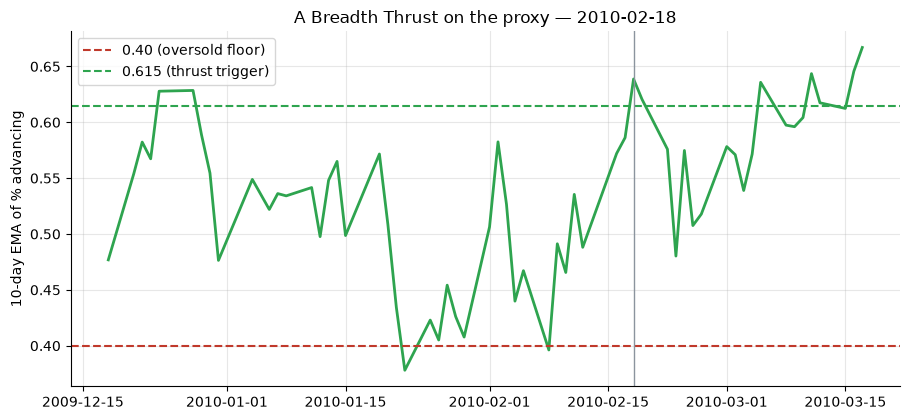

this thrust completed on 2010-02-18


In [2]:
if HAVE_REAL:
    e = st.breadth_ema(F['adv_ratio'])
    d0 = EVENTS[10]                       # one representative thrust
    lo = F.index.get_loc(d0)
    seg = e.iloc[max(0,lo-40):lo+20]
    fig, ax = plt.subplots(figsize=(9.2, 4.3))
    ax.plot(seg.index, seg.values, c=GREEN, lw=2)
    ax.axhline(0.40, ls='--', c=RED, label='0.40 (oversold floor)')
    ax.axhline(0.615, ls='--', c=GREEN, label='0.615 (thrust trigger)')
    ax.axvline(d0, c=GREY, lw=1)
    ax.set_title(f'A Breadth Thrust on the proxy — {d0.date()}')
    ax.set_ylabel('10-day EMA of % advancing'); ax.legend()
    plt.tight_layout(); plt.show()
    print('this thrust completed on', d0.date())
else:
    print('no cache — see docs/results.md for the frozen example (thrust 2010-02-18 etc.)')

Vivid, isn't it? The proxy fires **22** times in 32 years — about once every 1.4 years (the true NYSE version is rarer still, ~once a decade). Now the real question: what happens *after*?

**The payoff vs a normal day.** For each horizon, the thrust's average forward return and win-rate, next to the *unconditional* base rate — what a random day gives you anyway.

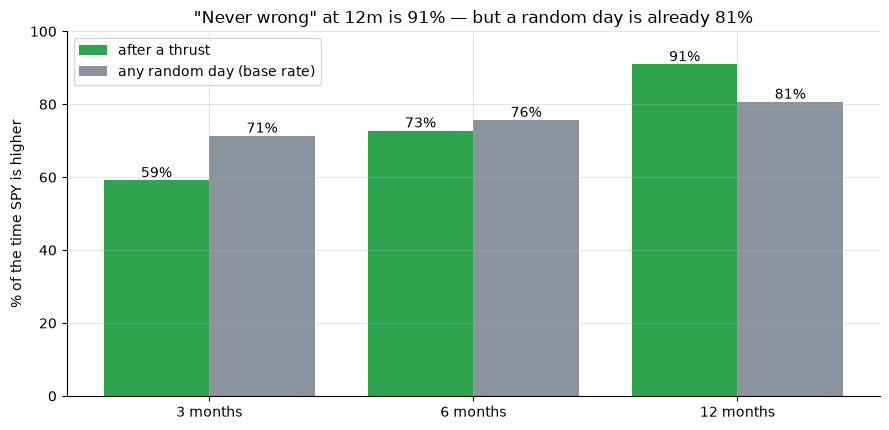

thrust 12m win-rate: 91%  base 12m win-rate: 81%


In [3]:
hs = [3, 6, 12]
if HAVE_REAL:
    rows = [st.summarize(F, EVENTS, m) for m in hs]
    cwin = [r['cond_win']*100 for r in rows]; bwin = [r['base_win']*100 for r in rows]
else:
    cwin = [R['h3'][3], R['h6'][3], R['h12'][3]]
    bwin = [R['h3'][5], R['h6'][5], R['h12'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, cwin, .4, color=GREEN, label='after a thrust')
ax.bar(x+.2, bwin, .4, color=GREY, label='any random day (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylim(0, 100); ax.set_ylabel('% of the time SPY is higher')
ax.set_title('"Never wrong" at 12m is 91% — but a random day is already 81%')
for i,(c,b) in enumerate(zip(cwin,bwin)):
    ax.annotate(f'{c:.0f}%',(i-.2,c),ha='center',va='bottom')
    ax.annotate(f'{b:.0f}%',(i+.2,b),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print('thrust 12m win-rate:', f'{cwin[-1]:.0f}%', ' base 12m win-rate:', f'{bwin[-1]:.0f}%')

There's the trick. The famous **91%** "never wrong" 12-month win-rate sits barely above the **81%** you get on *any* random day — because the US market simply rises most years. At **3 months** the thrust's win-rate (**59%**) is actually *below* the base rate (**71%**). The headline number is mostly the market's own up-drift, not the signal.

**Could a dozen random days look this good?** Here's the honest test: draw **22** *random* dates over and over, and see how the thrust's 12-month average return stacks up against pure luck.

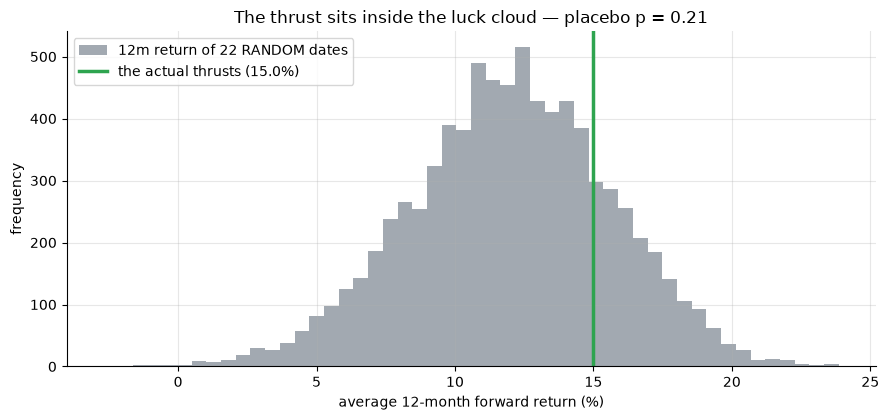

a random 22-date draw beats the thrust 21% of the time — far from rare


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(F, EVENTS, 12)
    obs = pl['thrust_mean']; pmean = pl['placebo_mean']; pval = pl['p_value']
    # rebuild the placebo distribution for the picture
    h = st.TRADING_DAYS[12]; spy = F['spy'].values; n=len(spy); k=len(EVENTS); lag=1
    vh = n - h - lag - 1; fwd = spy[lag+h:lag+h+vh]/spy[lag:lag+vh]-1
    rng = np.random.default_rng(361)
    draws = np.array([fwd[rng.integers(0,vh,size=k)].mean() for _ in range(8000)])
else:
    obs = R['h12'][2]/100; pmean = R['h12'][4]/100; pval = R['h12'][7]
    rng = np.random.default_rng(361); draws = rng.normal(pmean, 0.045, 8000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=50, color=GREY, alpha=.8, label='12m return of 22 RANDOM dates')
ax.axvline(obs*100, c=GREEN, lw=2.5, label=f'the actual thrusts ({obs*100:.1f}%)')
ax.set_xlabel('average 12-month forward return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The thrust sits inside the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random 22-date draw beats the thrust {pval*100:.0f}% of the time — far from rare')

The green line — the actual thrusts — falls **inside** the grey cloud of random draws. About **21%** of random 22-date samples do as well or better. In plain terms: **the thrust's record is what you'd expect from a dozen lucky coin-flips in an up-trending market.** Not magic — arithmetic.

## 5 · The verdict

- **Signal — Weak.** The pattern is real and the 12-month win-rate is genuinely high (**91%**) — but it barely beats the **81%** base rate, isn't statistically significant, and flips *negative* at 3 months. Real as lore, weak as edge.
- **Tradability — Fragile.** Even if the bump were real, **22 signals in 32 years** (the true version: once a decade) can't be a strategy you allocate to.
- **"Never wrong"? — Busted.** A dozen-ish events in a market that mostly rises *will* look perfect by luck. It's the [Hindenburg Omen](../../167-hindenburg-omen/) in reverse.

## 6 · Could you actually trade it? — count the trades

Forget significance for a second and just ask the operational question: how *often* does this thing tell you to do anything? Here's every thrust on the calendar — and the punchline is the empty space between them.

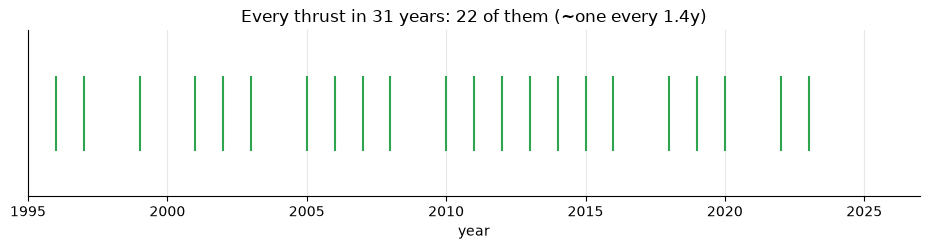

22 trades in 31 years -> one signal every ~1.4 years. Costs are tiny; frequency is fatal.


In [5]:
if HAVE_REAL:
    yrs = [d.year for d in EVENTS]
else:
    yrs = [1996,1997,1999,2001,2002,2003,2005,2006,2007,2008,2010,2011,2012,2013,2014,2015,2016,2018,2019,2020,2022,2023]
fig, ax = plt.subplots(figsize=(9.4, 2.6))
ax.eventplot(yrs, colors=GREEN, lineoffsets=0, linelengths=.8)
ax.set_yticks([]); ax.set_xlim(1995, 2027)
ax.set_title(f'Every thrust in 31 years: {len(yrs)} of them (~one every 1.4y)')
ax.set_xlabel('year'); plt.tight_layout(); plt.show()
gap = (2026-1995)/len(yrs)
print(f'{len(yrs)} trades in 31 years -> one signal every ~{gap:.1f} years. Costs are tiny; frequency is fatal.')

Around **22 trades in three decades.** A 5-bps cost barely scratches a multi-month hold — costs are *not* the problem. **Frequency is.** You can't build a portfolio around a rule that whispers once a year (and the genuine NYSE thrust speaks once a *decade*). The honest version isn't "wait for the all-clear and back up the truck" — it's "there aren't enough all-clears to matter."

## 7 · Going further 🚪

- **The mirror image.** [Study 167 — Hindenburg Omen](../../167-hindenburg-omen/) is the same rare-breadth signal pointed the *other* way: it "always" precedes crashes. Both owe their spooky records to the same thing — too few events in a drifting market.
- **The raw material.** [Study 168 — Advance-Decline](../../168-advance-decline/) asks whether the breadth line itself adds anything beyond price.
- **Build your own breadth.** Swap our 40-name basket for the S&P 500 and re-run the detector — the event count changes, the lesson doesn't: a signal this rare can't clear the bar.

*Think the thrust beats the market by more than luck? Capture the events, draw the same number of random dates, and show the thrust landing **outside** the cloud — then we'll talk.*